# PRISM Clinical Confidence Layer — Revised
## Unsupervised Clustering of High-Benefit Patient Archetypes

This is a revised version of the original Clinical Confidence Layer notebook, with changes targeted at the low silhouette score (0.093) and weak bootstrap stability (mean ARI 0.36) observed in the original run.

**Changes made, in order of expected impact:**

1. **PCA dimensionality reduction before clustering** — cluster in a reduced space (~90% variance retained) instead of raw 12-D, given only ~140 training points.
2. **Correlation pruning of SHAP-selected features** — drop redundant utilization/cost/risk features before feature selection, so the 12 slots aren't spent on near-duplicate signals.
3. **`covariance_type="diag"` instead of `"full"`** for the GMM, plus a higher `reg_covar` — drastically fewer free parameters relative to n=140.
4. **Capped k range** (2–5 instead of 2–8) — with n≈140 post-PCA, searching up to k=8 invites tiny, unstable clusters.
5. **Recalibrated confidence score** — the original GMM posterior (≈1.0 for every test patient) and KDE density (≈0.0 for every test patient) were degenerate and contributed no signal. This version checks for and flags that degeneracy, and lets you fall back to a k-NN-only score if the other two components still don't discriminate after fixes 1–4.

Everything else (data loading, train/test reconstruction, output structure, ground-truth sanity check) is unchanged from the original.

---
## Setup and Imports
---

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors, KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

try:
    from sklearn.cluster import HDBSCAN
except ImportError:
    from hdbscan import HDBSCAN

# Path setup for _prism_model_utils
for candidate in [Path.cwd(), Path.cwd() / 'Code']:
    if (candidate / '_prism_model_utils.py').exists():
        sys.path.insert(0, str(candidate))
        break

from _prism_model_utils import (
    project_root,
    ensure_output_folder,
    split_train_test,
    ntile_desc,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = project_root()
SEED = 123
np.random.seed(SEED)

print('Project root:', PROJECT_ROOT)

Project root: /home/sagemaker-user/prism_repo


---
## Step 1 – Load DR-Learner Outputs

Load the scored outputs from the Doubly Robust notebook. Reconstruct the train/test split
using the same deterministic parameters (seed=123, fraction=0.70, stratified).
*(Unchanged from original.)*
---

In [2]:
# --- Configuration ---
DR_OUTPUT_DIR = PROJECT_ROOT / 'Outputs' / 'Doubly-Robust' / 'Python'
OUTPUT_DIR = ensure_output_folder(PROJECT_ROOT / 'Outputs' / 'Clinical-Confidence-Revised' / 'Python')

TRAIN_FRACTION = 0.70
HIGH_BENEFIT_PERCENTILE = 0.20  # Top 20%
N_SHAP_FEATURES = 12  # Candidate pool before correlation pruning
CORR_PRUNE_THRESHOLD = 0.80  # NEW: drop features correlated above this with an already-kept feature
PCA_VARIANCE_TARGET = 0.90  # NEW: retain components explaining this much variance
N_BOOTSTRAP = 100  # Bootstrap iterations for stability
KNN_K = 10  # k for nearest-neighbor similarity

# --- Load DR-learner scored full population ---
scored_full = pd.read_csv(DR_OUTPUT_DIR / 'doubly_robust_scored_output.csv')
scored_test = pd.read_csv(DR_OUTPUT_DIR / 'doubly_robust_scored_test_output.csv')
shap_importance = pd.read_csv(DR_OUTPUT_DIR / 'doubly_robust_global_benefit_shap_importance.csv')

print(f'Full scored population: {len(scored_full)} members')
print(f'Test scored population: {len(scored_test)} members')
print(f'SHAP features available: {len(shap_importance)}')

# --- Reconstruct train/test split (same deterministic split as DR notebook) ---
train_df, test_df = split_train_test(
    scored_full,
    train_fraction=TRAIN_FRACTION,
    seed=SEED,
    stratify_columns=['intervention_flag', 'outcome_ed_90d'],
)

print(f'\nReconstructed split:')
print(f'  Training: {len(train_df)} members')
print(f'  Test: {len(test_df)} members')
print(f'\nBenefit score range (train): [{train_df["benefit_score"].min():.4f}, {train_df["benefit_score"].max():.4f}]')
print(f'Benefit score range (test): [{test_df["benefit_score"].min():.4f}, {test_df["benefit_score"].max():.4f}]')

Full scored population: 1000 members
Test scored population: 300 members
SHAP features available: 77

Reconstructed split:
  Training: 700 members
  Test: 300 members

Benefit score range (train): [-0.0076, 0.0950]
Benefit score range (test): [0.0107, 0.0798]


---
## Step 2 – Construct High-Benefit Reference Population

Select the top 20% of training members by predicted benefit score.
*(Unchanged from original.)*
---

In [3]:
# --- Select top 20% high-benefit training patients ---
benefit_threshold_train = train_df['benefit_score'].quantile(1 - HIGH_BENEFIT_PERCENTILE)
high_benefit_train = train_df[train_df['benefit_score'] >= benefit_threshold_train].copy()

# --- Similarly for test ---
benefit_threshold_test = test_df['benefit_score'].quantile(1 - HIGH_BENEFIT_PERCENTILE)
high_benefit_test = test_df[test_df['benefit_score'] >= benefit_threshold_test].copy()

print(f'High-benefit training population: {len(high_benefit_train)} members')
print(f'  Benefit score threshold: >= {benefit_threshold_train:.4f}')
print(f'  Mean benefit score: {high_benefit_train["benefit_score"].mean():.4f}')
print(f'\nHigh-benefit test population: {len(high_benefit_test)} members')
print(f'  Benefit score threshold: >= {benefit_threshold_test:.4f}')
print(f'  Mean benefit score: {high_benefit_test["benefit_score"].mean():.4f}')

High-benefit training population: 140 members
  Benefit score threshold: >= 0.0568
  Mean benefit score: 0.0671

High-benefit test population: 60 members
  Benefit score threshold: >= 0.0555
  Mean benefit score: 0.0639


---
## Step 3 – Feature Selection for Clustering (SHAP-Based + Correlation Pruning)

**CHANGED:** the original took the top 12 SHAP features directly. Several of those (`current_risk_score`, `percolator_utilization_score`, `total_cost_last_6m`, `ed_visits_last_6m`, `rx_count_last_6m`) are different measurements of the same underlying 'how sick/costly is this patient' signal — they eat up dimensions without adding real separating structure. This version walks the SHAP-ranked list in order and greedily skips any feature whose absolute correlation with an already-kept feature exceeds `CORR_PRUNE_THRESHOLD`.
---

In [4]:
# --- Candidate pool: take a larger slice of the SHAP ranking than we need, so pruning ---
# --- still leaves enough features to fill N_SHAP_FEATURES ---
candidate_pool = shap_importance.nlargest(min(len(shap_importance), N_SHAP_FEATURES * 3), 'mean_abs_benefit_shap')['feature'].tolist()
candidate_pool = [f for f in candidate_pool if f in high_benefit_train.columns]

candidate_matrix = high_benefit_train[candidate_pool].apply(pd.to_numeric, errors='coerce').fillna(0)
corr_matrix = candidate_matrix.corr().abs()

# --- Greedy correlation pruning (NEW) ---
kept_features = []
dropped_features = []
for feat in candidate_pool:
    if not kept_features:
        kept_features.append(feat)
        continue
    max_corr_with_kept = corr_matrix.loc[feat, kept_features].max()
    if max_corr_with_kept >= CORR_PRUNE_THRESHOLD:
        dropped_features.append((feat, max_corr_with_kept))
    else:
        kept_features.append(feat)
    if len(kept_features) >= N_SHAP_FEATURES:
        break

CLUSTER_FEATURES = kept_features[:N_SHAP_FEATURES]

print(f'Selected {len(CLUSTER_FEATURES)} features for clustering (after correlation pruning):')
for i, feat in enumerate(CLUSTER_FEATURES, 1):
    shap_val = shap_importance.loc[shap_importance['feature'] == feat, 'mean_abs_benefit_shap']
    shap_str = f'{shap_val.values[0]:.4f}' if len(shap_val) > 0 else 'N/A'
    print(f'  {i:2d}. {feat} (mean |SHAP| = {shap_str})')

if dropped_features:
    print(f'\nDropped as redundant (corr >= {CORR_PRUNE_THRESHOLD} with a higher-ranked kept feature):')
    for feat, c in dropped_features:
        print(f'  {feat} (corr = {c:.2f})')

# --- Extract feature matrices ---
X_train_raw = high_benefit_train[CLUSTER_FEATURES].copy()
X_test_raw = high_benefit_test[CLUSTER_FEATURES].copy()

# Ensure numeric (coerce any categorical stragglers)
X_train_raw = X_train_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_raw = X_test_raw.apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Standardize: fit ONLY on training high-benefit patients ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)  # No data leakage

print(f'\nScaled training matrix shape: {X_train_scaled.shape}')
print(f'Scaled test matrix shape: {X_test_scaled.shape}')

Selected 12 features for clustering (after correlation pruning):
   1. percolator_clinical_score (mean |SHAP| = 0.0040)
   2. age (mean |SHAP| = 0.0040)
   3. current_risk_score (mean |SHAP| = 0.0030)
   4. percolator_utilization_score (mean |SHAP| = 0.0022)
   5. med_adherence_pdc (mean |SHAP| = 0.0021)
   6. percolator_sdoh_score (mean |SHAP| = 0.0017)
   7. pcp_visits_last_6m (mean |SHAP| = 0.0015)
   8. ed_visits_last_6m (mean |SHAP| = 0.0015)
   9. rx_count_last_6m (mean |SHAP| = 0.0013)
  10. total_cost_last_6m (mean |SHAP| = 0.0011)
  11. anxiety_flag (mean |SHAP| = 0.0010)
  12. copd_flag (mean |SHAP| = 0.0006)

Scaled training matrix shape: (140, 12)
Scaled test matrix shape: (60, 12)


---
## Step 3b – Dimensionality Reduction (NEW)

With only ~140 training patients, clustering directly in 12-D asks a `covariance_type="full"` GMM to fit far more parameters than there are data points. This step reduces to a PCA space retaining `PCA_VARIANCE_TARGET` of the variance and clusters there instead. Archetypes are still profiled back on the original clinical features in Step 4.
---

In [5]:
pca_cluster = PCA(n_components=PCA_VARIANCE_TARGET, random_state=SEED)
X_train_pca = pca_cluster.fit_transform(X_train_scaled)
X_test_pca = pca_cluster.transform(X_test_scaled)

print(f'PCA components retained: {pca_cluster.n_components_} (target variance = {PCA_VARIANCE_TARGET:.0%})')
print(f'Variance explained per component: {np.round(pca_cluster.explained_variance_ratio_, 3)}')
print(f'Cumulative variance explained: {pca_cluster.explained_variance_ratio_.sum():.1%}')
print(f'\nTraining matrix for clustering: {X_train_pca.shape}  (was {X_train_scaled.shape})')
print(f'Test matrix for clustering: {X_test_pca.shape}  (was {X_test_scaled.shape})')

# From here on, clustering happens on X_train_pca / X_test_pca rather than the raw scaled features.
# Kept for reference/profiling: X_train_scaled, X_test_scaled (original standardized clinical features).

PCA components retained: 8 (target variance = 90%)
Variance explained per component: [0.264 0.199 0.114 0.098 0.08  0.06  0.049 0.046]
Cumulative variance explained: 91.0%

Training matrix for clustering: (140, 8)  (was (140, 12))
Test matrix for clustering: (60, 8)  (was (60, 12))


---
## Step 4 – Discover High-Benefit Patient Archetypes

**Primary method:** Gaussian Mixture Model (GMM) with BIC-based component selection.
**Stability checks:** K-Means and Agglomerative Clustering.
**Diagnostic layer:** HDBSCAN for noise/outlier detection.

**CHANGED:**
- Clustering runs on `X_train_pca` (was `X_train_scaled`).
- `k_range` capped at 2–5 (was 2–8) — with n≈140 post-PCA, searching up to 8 invited tiny, unstable clusters (the original run put only 6-10 patients in 3 of its 6 clusters).
- GMM uses `covariance_type="diag"` with an explicit `reg_covar` (was `"full"` with default `reg_covar`) — far fewer free parameters relative to n, and less prone to the near-singular, overconfident covariances that made every test-patient posterior collapse to 1.0.
---

GMM MODEL SELECTION (PCA space, diag covariance)
BIC-optimal number of clusters: 2
BIC scores: {2: 3420.1, 3: 3444.3, 4: 3493.8, 5: 3519.8}


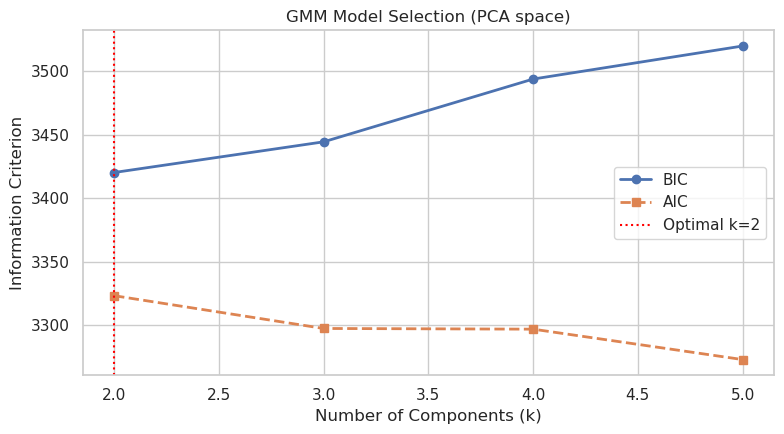



K-MEANS MODEL SELECTION
Highest silhouette at k = 2


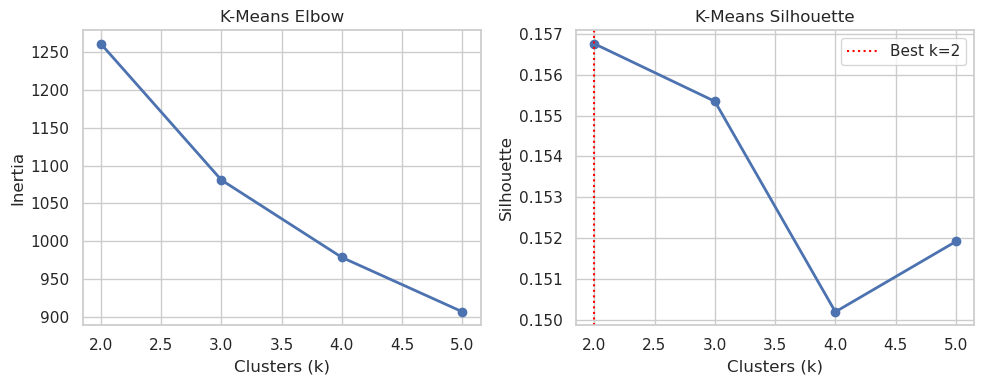



CLUSTER SUMMARIES

GMM
{0: 105, 1: 35}

K-Means
Inertia: 1261.12
{0: 57, 1: 83}

Agglomerative
{0: 125, 1: 15}

HDBSCAN
Clusters found: 2
Noise points: 22 (15.7%)
{-1: 22, 0: 99, 1: 19}


SILHOUETTE SCORES (PCA space)
GMM:            0.011
K-Means:        0.157
Agglomerative:  0.193
HDBSCAN:        0.114


CROSS-METHOD AGREEMENT (ARI)
GMM vs K-Means:        -0.013
GMM vs Agglomerative:  0.094
K-Means vs Agglomerative: -0.024


In [6]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

GMM_COVARIANCE_TYPE = 'diag'  # CHANGED from 'full'
GMM_REG_COVAR = 1e-3          # CHANGED from sklearn default (1e-6)

# =============================================================================
# GMM MODEL SELECTION (PRIMARY ANALYSIS)
# =============================================================================

k_range = range(2, 6)  # CHANGED from range(2, 9)
bic_scores = []
aic_scores = []

for k in k_range:

    gmm_candidate = GaussianMixture(
        n_components=k,
        covariance_type=GMM_COVARIANCE_TYPE,
        reg_covar=GMM_REG_COVAR,
        random_state=SEED,
        n_init=10,
    )

    gmm_candidate.fit(X_train_pca)

    bic_scores.append(gmm_candidate.bic(X_train_pca))
    aic_scores.append(gmm_candidate.aic(X_train_pca))

optimal_k = list(k_range)[np.argmin(bic_scores)]

print('=' * 70)
print('GMM MODEL SELECTION (PCA space, diag covariance)')
print('=' * 70)
print(f'BIC-optimal number of clusters: {optimal_k}')
print(f'BIC scores: {dict(zip(k_range, np.round(bic_scores,1)))}')

# Plot
fig, ax = plt.subplots(figsize=(8,4.5))

ax.plot(k_range, bic_scores, 'o-', linewidth=2, label='BIC')
ax.plot(k_range, aic_scores, 's--', linewidth=2, label='AIC')

ax.axvline(
    optimal_k,
    color='red',
    linestyle=':',
    label=f'Optimal k={optimal_k}',
)

ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection (PCA space)')
ax.legend()

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / 'gmm_bic_aic_selection.png',
    dpi=150,
)

plt.show()

# =============================================================================
# K-MEANS MODEL SELECTION (DIAGNOSTIC ONLY)
# =============================================================================

inertia = []
kmeans_silhouette = []

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=20,
    )

    labels = km.fit_predict(X_train_pca)

    inertia.append(km.inertia_)
    kmeans_silhouette.append(
        silhouette_score(X_train_pca, labels)
    )

best_kmeans_k = list(k_range)[np.argmax(kmeans_silhouette)]

print('\n')
print('=' * 70)
print('K-MEANS MODEL SELECTION')
print('=' * 70)
print(f'Highest silhouette at k = {best_kmeans_k}')

fig, ax = plt.subplots(1,2,figsize=(10,4))

# Elbow
ax[0].plot(k_range, inertia, 'o-', linewidth=2)
ax[0].set_xlabel('Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('K-Means Elbow')

# Silhouette
ax[1].plot(k_range, kmeans_silhouette, 'o-', linewidth=2)
ax[1].axvline(
    best_kmeans_k,
    color='red',
    linestyle=':',
    label=f'Best k={best_kmeans_k}',
)
ax[1].legend()
ax[1].set_xlabel('Clusters (k)')
ax[1].set_ylabel('Silhouette')
ax[1].set_title('K-Means Silhouette')

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL CLUSTERING MODELS
# (ALL USE GMM-SELECTED NUMBER OF CLUSTERS, ALL ON PCA-REDUCED DATA)
# =============================================================================

# ----- Gaussian Mixture -----

gmm = GaussianMixture(
    n_components=optimal_k,
    covariance_type=GMM_COVARIANCE_TYPE,
    reg_covar=GMM_REG_COVAR,
    random_state=SEED,
    n_init=10,
)

gmm_labels = gmm.fit_predict(X_train_pca)

# ----- K-Means -----

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=SEED,
    n_init=20,
)

kmeans_labels = kmeans.fit_predict(X_train_pca)

# ----- Agglomerative -----

agg = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage='ward',
)

agg_labels = agg.fit_predict(X_train_pca)

# ----- HDBSCAN -----

hdbscan_model = HDBSCAN(
    min_cluster_size=max(5, len(X_train_pca) // 20),  # CHANGED: scale with n rather than fixed 5
    min_samples=3,
)

hdbscan_labels = hdbscan_model.fit_predict(X_train_pca)

# =============================================================================
# CLUSTER SUMMARIES
# =============================================================================

print('\n')
print('=' * 70)
print('CLUSTER SUMMARIES')
print('=' * 70)

print('\nGMM')
print(dict(zip(*np.unique(gmm_labels, return_counts=True))))

print('\nK-Means')
print(f'Inertia: {kmeans.inertia_:.2f}')
print(dict(zip(*np.unique(kmeans_labels, return_counts=True))))

print('\nAgglomerative')
print(dict(zip(*np.unique(agg_labels, return_counts=True))))

print('\nHDBSCAN')

noise = np.sum(hdbscan_labels == -1)

print(f'Clusters found: {len(set(hdbscan_labels)-{-1})}')
print(f'Noise points: {noise} ({noise/len(hdbscan_labels):.1%})')
print(dict(zip(*np.unique(hdbscan_labels, return_counts=True))))

# =============================================================================
# SILHOUETTE SCORES
# =============================================================================

sil_gmm = silhouette_score(X_train_pca, gmm_labels)
sil_kmeans = silhouette_score(X_train_pca, kmeans_labels)
sil_agg = silhouette_score(X_train_pca, agg_labels)

mask = hdbscan_labels != -1

if len(np.unique(hdbscan_labels[mask])) >= 2:
    sil_hdbscan = silhouette_score(
        X_train_pca[mask],
        hdbscan_labels[mask],
    )
else:
    sil_hdbscan = np.nan

print('\n')
print('=' * 70)
print('SILHOUETTE SCORES (PCA space)')
print('=' * 70)

print(f'GMM:            {sil_gmm:.3f}')
print(f'K-Means:        {sil_kmeans:.3f}')
print(f'Agglomerative:  {sil_agg:.3f}')

if np.isnan(sil_hdbscan):
    print('HDBSCAN:        Not available')
else:
    print(f'HDBSCAN:        {sil_hdbscan:.3f}')

# =============================================================================
# CROSS-METHOD AGREEMENT
# =============================================================================

ari_gmm_kmeans = adjusted_rand_score(
    gmm_labels,
    kmeans_labels,
)

ari_gmm_agg = adjusted_rand_score(
    gmm_labels,
    agg_labels,
)

ari_kmeans_agg = adjusted_rand_score(
    kmeans_labels,
    agg_labels,
)

print('\n')
print('=' * 70)
print('CROSS-METHOD AGREEMENT (ARI)')
print('=' * 70)

print(f'GMM vs K-Means:        {ari_gmm_kmeans:.3f}')
print(f'GMM vs Agglomerative:  {ari_gmm_agg:.3f}')
print(f'K-Means vs Agglomerative: {ari_kmeans_agg:.3f}')

### Archetype Profiles

Summarize each discovered archetype by clinical characteristics (original, non-PCA features — unchanged approach from the original notebook, just re-pointed at the new cluster labels).

In [8]:
# --- Build archetype profiles ---
high_benefit_train_labeled = high_benefit_train.copy()
high_benefit_train_labeled['archetype'] = gmm_labels

# Summary by archetype
profile_features = CLUSTER_FEATURES + ['benefit_score']
if 'current_risk_score' in high_benefit_train.columns and 'current_risk_score' not in profile_features:
    profile_features.append('current_risk_score')

archetype_profiles = (
    high_benefit_train_labeled
    .groupby('archetype')[profile_features]
    .agg(['mean', 'std', 'count'])
)

# Simplified summary table
archetype_summary_rows = []
for cluster_id in sorted(high_benefit_train_labeled['archetype'].unique()):
    cluster_data = high_benefit_train_labeled[high_benefit_train_labeled['archetype'] == cluster_id]
    row = {
        'archetype': cluster_id,
        'n_patients': len(cluster_data),
        'avg_benefit_score': cluster_data['benefit_score'].mean(),
    }
    for feat in CLUSTER_FEATURES:
        if feat in cluster_data.columns:
            row[f'avg_{feat}'] = cluster_data[feat].mean()
    archetype_summary_rows.append(row)

archetype_summary = pd.DataFrame(archetype_summary_rows)
archetype_summary.to_csv(OUTPUT_DIR / 'archetype_summary.csv', index=False)

print('Archetype Summary:')
display(archetype_summary)

Archetype Summary:


,archetype,n_patients,avg_benefit_score,avg_percolator_clinical_score,avg_age,avg_current_risk_score,avg_percolator_utilization_score,avg_med_adherence_pdc,avg_percolator_sdoh_score,avg_pcp_visits_last_6m,avg_ed_visits_last_6m,avg_rx_count_last_6m,avg_total_cost_last_6m,avg_anxiety_flag,avg_copd_flag
0,0,105,0.066662,61.791429,61.828571,54.105714,54.356190,0.755533,36.773333,3.580952,1.447619,9.047619,5264.250952,0.32381,0.504762
1,1,35,0.068523,59.688571,55.657143,51.171429,51.688571,0.775343,29.374286,2.000000,1.171429,8.457143,4744.378571,0.00000,0.000000


---
## Step 5 – Validate Cluster Stability

Stability is a gating step. If archetypes aren't reproducible at n~140, they shouldn't
be presented as clinical phenotypes.

**CHANGED:** bootstrap resamples and refits in PCA space (`X_train_pca`) with the same `diag` covariance / `reg_covar` settings as the main model, so the stability check matches the model actually being validated.
---

In [10]:
# --- Internal validation metrics ---
sil_score = silhouette_score(X_train_pca, gmm_labels)
db_score = davies_bouldin_score(X_train_pca, gmm_labels)
ch_score = calinski_harabasz_score(X_train_pca, gmm_labels)

print('Internal Cluster Validation (GMM primary, PCA space):')
print(f'  Silhouette Score: {sil_score:.3f} (higher is better, range [-1, 1])')
print(f'  Davies-Bouldin Index: {db_score:.3f} (lower is better)')
print(f'  Calinski-Harabasz Index: {ch_score:.1f} (higher is better)')

# --- Bootstrap resampling for stability ---
rng = np.random.default_rng(SEED)
bootstrap_ari_scores = []

for i in range(N_BOOTSTRAP):
    indices = rng.choice(len(X_train_pca), size=len(X_train_pca), replace=True)
    X_boot = X_train_pca[indices]
    gmm_boot = GaussianMixture(
        n_components=optimal_k,
        covariance_type=GMM_COVARIANCE_TYPE,
        reg_covar=GMM_REG_COVAR,
        random_state=SEED + i,
        n_init=5,
    )
    gmm_boot.fit(X_boot)
    boot_labels = gmm_boot.predict(X_train_pca)
    ari = adjusted_rand_score(gmm_labels, boot_labels)
    bootstrap_ari_scores.append(ari)

bootstrap_ari = np.array(bootstrap_ari_scores)
print(f'\nBootstrap Stability ({N_BOOTSTRAP} iterations):')
print(f'  Mean ARI: {bootstrap_ari.mean():.3f}')
print(f'  Std ARI: {bootstrap_ari.std():.3f}')
print(f'  Median ARI: {np.median(bootstrap_ari):.3f}')

stability_assessment = 'STRONG' if bootstrap_ari.mean() > 0.7 else ('MODERATE' if bootstrap_ari.mean() > 0.5 else 'WEAK')
print(f'  Stability assessment: {stability_assessment}')

stability_summary = pd.DataFrame([{
    'n_components': optimal_k, 'silhouette_score': sil_score,
    'davies_bouldin_index': db_score, 'calinski_harabasz_index': ch_score,
    'bootstrap_mean_ari': bootstrap_ari.mean(), 'bootstrap_std_ari': bootstrap_ari.std(),
    'ari_gmm_vs_kmeans': ari_gmm_kmeans, 'ari_gmm_vs_agglomerative': ari_gmm_agg,
    'stability_assessment': stability_assessment,
}])
stability_summary.to_csv(OUTPUT_DIR / 'cluster_stability_summary.csv', index=False)
display(stability_summary)

Internal Cluster Validation (GMM primary, PCA space):
  Silhouette Score: 0.011 (higher is better, range [-1, 1])
  Davies-Bouldin Index: 3.186 (lower is better)
  Calinski-Harabasz Index: 7.8 (higher is better)



Bootstrap Stability (100 iterations):
  Mean ARI: 0.172
  Std ARI: 0.241
  Median ARI: 0.088
  Stability assessment: WEAK


,n_components,silhouette_score,davies_bouldin_index,calinski_harabasz_index,bootstrap_mean_ari,bootstrap_std_ari,ari_gmm_vs_kmeans,ari_gmm_vs_agglomerative,stability_assessment
0,2,0.011138,3.186354,7.764877,0.172006,0.241498,-0.013198,0.094259,WEAK


---
## Steps 6 & 7 – Score Test Patients Against Historical Clusters

**CHANGED:** all scoring runs on PCA-reduced features (`X_train_pca`/`X_test_pca`). The KDE bandwidth is still computed with the same heuristic but now in the much lower-dimensional PCA space, where it's far less likely to collapse to zero everywhere. A diagnostic check is added that flags a component as degenerate if it doesn't vary across test patients (this is what happened to GMM posterior and KDE density in the original run).
---

In [11]:
# --- 1. GMM Posterior Probabilities ---
test_gmm_proba = gmm.predict_proba(X_test_pca)
test_gmm_max_posterior = test_gmm_proba.max(axis=1)
test_gmm_labels = gmm.predict(X_test_pca)

print('GMM Posterior (test high-benefit):')
print(f'  Mean max posterior: {test_gmm_max_posterior.mean():.3f}')
print(f'  Std max posterior:  {test_gmm_max_posterior.std():.3f}')
print(f'  Patients with posterior > 0.8: {(test_gmm_max_posterior > 0.8).sum()}')

# --- 2. k-NN Distance ---
knn = NearestNeighbors(n_neighbors=KNN_K, metric='euclidean')
knn.fit(X_train_pca)
distances, _ = knn.kneighbors(X_test_pca)
mean_knn_distance = distances.mean(axis=1)
knn_similarity = 1.0 / (1.0 + mean_knn_distance)

print(f'\nk-NN Similarity (k={KNN_K}): mean={knn_similarity.mean():.3f}, std={knn_similarity.std():.3f}')

# --- 3. Local Density (KDE), now in PCA space ---
n_train = len(X_train_pca)
d_features = X_train_pca.shape[1]
bandwidth = n_train ** (-1.0 / (d_features + 4))
kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
kde.fit(X_train_pca)

train_log_density = kde.score_samples(X_train_pca)
test_log_density = kde.score_samples(X_test_pca)
density_min, density_max = train_log_density.min(), train_log_density.max()
density_range = max(density_max - density_min, 1e-10)
test_density_normalized = np.clip((test_log_density - density_min) / density_range, 0, 1)

print(f'  Local Density: mean={test_density_normalized.mean():.3f}, std={test_density_normalized.std():.3f}')

# --- 4. HDBSCAN Diagnostic ---
try:
    from hdbscan import approximate_predict
    test_hdbscan_labels, _ = approximate_predict(hdbscan_model, X_test_pca)
except (ImportError, AttributeError, Exception):
    combined_pca = np.vstack([X_train_pca, X_test_pca])
    hdb_comb = HDBSCAN(min_cluster_size=max(5, len(X_train_pca) // 20), min_samples=5)
    comb_labels = hdb_comb.fit_predict(combined_pca)
    test_hdbscan_labels = comb_labels[len(X_train_pca):]

test_hdbscan_noise = (test_hdbscan_labels == -1)
print(f'  HDBSCAN noise: {test_hdbscan_noise.sum()} ({test_hdbscan_noise.mean():.1%})')

# --- NEW: degeneracy diagnostic ---
# A scoring component that doesn't vary across test patients (std ~ 0) is not contributing
# any discriminating information, no matter how it's weighted downstream.
DEGENERACY_STD_THRESHOLD = 0.01
component_stds = {
    'gmm_posterior': test_gmm_max_posterior.std(),
    'knn_similarity': knn_similarity.std(),
    'density': test_density_normalized.std(),
}
degenerate_components = [name for name, s in component_stds.items() if s < DEGENERACY_STD_THRESHOLD]

print('\nComponent variability check:')
for name, s in component_stds.items():
    flag = '  <-- DEGENERATE (near-zero variance, contributes no signal)' if s < DEGENERACY_STD_THRESHOLD else ''
    print(f'  {name}: std={s:.4f}{flag}')
if degenerate_components:
    print(f'\n WARNING: {degenerate_components} still degenerate after PCA + diag covariance fixes.')
    print('  Consider dropping these from the confidence score below (see Step 8).')
else:
    print('\nAll three components show real variability across test patients — no degeneracy detected.')

GMM Posterior (test high-benefit):
  Mean max posterior: 0.908
  Std max posterior:  0.146
  Patients with posterior > 0.8: 48

k-NN Similarity (k=10): mean=0.291, std=0.040
  Local Density: mean=0.000, std=0.000
  HDBSCAN noise: 23 (38.3%)

Component variability check:
  gmm_posterior: std=0.1458
  knn_similarity: std=0.0396
  density: std=0.0000  <-- DEGENERATE (near-zero variance, contributes no signal)

  Consider dropping these from the confidence score below (see Step 8).


---
## Step 8 – Construct Clinical Confidence Score

**CHANGED:** any component flagged as degenerate in the previous step is automatically excluded from the blend (with a printed note), instead of being silently averaged in at equal weight the way the original notebook did.
---

In [12]:
components = {
    'gmm_posterior': test_gmm_max_posterior,
    'knn_similarity': knn_similarity,
    'density': test_density_normalized,
}

active_components = {k: v for k, v in components.items() if k not in degenerate_components}

if len(active_components) < len(components):
    print(f'Excluding degenerate component(s) from confidence score: {list(degenerate_components)}')
print(f'Confidence score built from: {list(active_components.keys())}')

confidence_score = np.mean(np.vstack(list(active_components.values())), axis=0)

# Min-max normalize to [0, 1]
cs_min, cs_max = confidence_score.min(), confidence_score.max()
cs_range = max(cs_max - cs_min, 1e-10)
confidence_score_normalized = (confidence_score - cs_min) / cs_range

print('\nClinical Confidence Score (test high-benefit):')
print(f'  Mean: {confidence_score_normalized.mean():.3f}')
print(f'  Std: {confidence_score_normalized.std():.3f}')
print(f'  Range: [{confidence_score_normalized.min():.3f}, {confidence_score_normalized.max():.3f}]')

Excluding degenerate component(s) from confidence score: ['density']
Confidence score built from: ['gmm_posterior', 'knn_similarity']

Clinical Confidence Score (test high-benefit):
  Mean: 0.732
  Std: 0.239
  Range: [0.000, 1.000]


Confidence thresholds:
Low    : < 0.321
Medium : 0.321 - 0.699
High   : >= 0.699


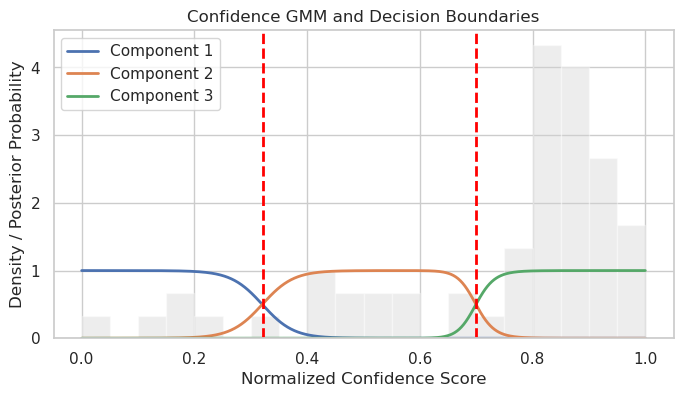

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Fit GMM
gmm_conf = GaussianMixture(
    n_components=3,
    random_state=SEED,
)
gmm_conf.fit(confidence_score_normalized.reshape(-1, 1))

# Predict cluster labels
labels = gmm_conf.predict(confidence_score_normalized.reshape(-1, 1))

# Order clusters by mean confidence
order = np.argsort(gmm_conf.means_.flatten())

# Relabel so:
# 0 = Low
# 1 = Medium
# 2 = High
mapping = {old: new for new, old in enumerate(order)}
labels = np.vectorize(mapping.get)(labels)

# Evaluate posterior probabilities on a dense grid
x = np.linspace(0, 1, 1000).reshape(-1, 1)
probs = gmm_conf.predict_proba(x)[:, order]

# Decision boundaries
pred = np.argmax(probs, axis=1)
boundaries = []

for i in range(len(pred) - 1):
    if pred[i] != pred[i + 1]:
        boundaries.append((x[i, 0] + x[i + 1, 0]) / 2)

print("Confidence thresholds:")
print(f"Low    : < {boundaries[0]:.3f}")
print(f"Medium : {boundaries[0]:.3f} - {boundaries[1]:.3f}")
print(f"High   : >= {boundaries[1]:.3f}")

# Visualization
plt.figure(figsize=(8,4))

plt.hist(
    confidence_score_normalized,
    bins=20,
    density=True,
    alpha=0.4,
    color="lightgray",
)

for k in range(3):
    plt.plot(
        x,
        probs[:, k],
        linewidth=2,
        label=f"Component {k+1}",
    )

for b in boundaries:
    plt.axvline(
        b,
        color="red",
        linestyle="--",
        linewidth=2,
    )

plt.xlabel("Normalized Confidence Score")
plt.ylabel("Density / Posterior Probability")
plt.title("Confidence GMM and Decision Boundaries")
plt.legend()

plt.show()

---
## Step 9 – Assign Confidence Categories

*(Unchanged from original.)*
---

In [30]:
# =============================================================================
# DATA-DRIVEN CONFIDENCE TIERS USING A 1D GMM
# =============================================================================

from sklearn.mixture import GaussianMixture

# Fit GMM to confidence scores
gmm_conf = GaussianMixture(
    n_components=3,
    random_state=SEED,
    n_init=20,
)

gmm_conf.fit(confidence_score_normalized.reshape(-1, 1))

# Raw labels
confidence_labels = gmm_conf.predict(
    confidence_score_normalized.reshape(-1, 1)
)

# Order components from lowest -> highest confidence
means = gmm_conf.means_.flatten()
order = np.argsort(means)

mapping = {
    order[0]: "Low",
    order[1]: "Medium",
    order[2]: "High",
}

confidence_tiers = np.array(
    [mapping[label] for label in confidence_labels]
)

# -------------------------------------------------------------------------
# Determine decision boundaries between components
# -------------------------------------------------------------------------

x = np.linspace(0, 1, 5000).reshape(-1, 1)

posterior = gmm_conf.predict_proba(x)[:, order]

winner = np.argmax(posterior, axis=1)

boundaries = []

for i in range(len(winner) - 1):
    if winner[i] != winner[i + 1]:
        boundaries.append((x[i, 0] + x[i + 1, 0]) / 2)

print("\nConfidence Thresholds (GMM-derived)")
print(f"Low    : < {boundaries[0]:.3f}")
print(f"Medium : {boundaries[0]:.3f} - {boundaries[1]:.3f}")
print(f"High   : >= {boundaries[1]:.3f}")

# -------------------------------------------------------------------------
# Save patient-level results
# -------------------------------------------------------------------------

scored_confidence = high_benefit_test.reset_index(drop=True).copy()

scored_confidence["gmm_archetype"] = test_gmm_labels
scored_confidence["gmm_max_posterior"] = test_gmm_max_posterior
scored_confidence["knn_similarity"] = knn_similarity
scored_confidence["density_normalized"] = test_density_normalized

scored_confidence["clinical_confidence_score"] = confidence_score_normalized
scored_confidence["confidence_tier"] = confidence_tiers

scored_confidence["hdbscan_noise_flag"] = (
    test_hdbscan_noise.astype(int)
)

# -------------------------------------------------------------------------
# Tier summary
# -------------------------------------------------------------------------

tier_summary = (
    scored_confidence
    .groupby("confidence_tier")
    .agg(
        n=("clinical_confidence_score", "count"),
        avg_confidence=("clinical_confidence_score", "mean"),
        avg_benefit=("benefit_score", "mean"),
        avg_posterior=("gmm_max_posterior", "mean"),
        avg_knn_sim=("knn_similarity", "mean"),
        avg_density=("density_normalized", "mean"),
    )
    .reindex(["High", "Medium", "Low"])
    .reset_index()
)

print("\nConfidence Tier Summary")
display(tier_summary)

tier_summary.to_csv(
    OUTPUT_DIR / "confidence_tier_summary.csv",
    index=False,
)

scored_confidence.to_csv(
    OUTPUT_DIR / "scored_confidence_test_patients.csv",
    index=False,
)


Confidence Thresholds (GMM-derived)
Low    : < 0.778
Medium : 0.778 - 0.833
High   : >= 0.833

Confidence Tier Summary


,confidence_tier,n,avg_confidence,avg_benefit,avg_posterior,avg_knn_sim,avg_density
0,High,26,0.903487,0.064632,0.992004,0.312077,0.0
1,Medium,15,0.810141,0.062722,0.987005,0.260089,0.0
2,Low,19,0.435675,0.063907,0.731034,0.287452,0.0


---
## Step 9a – Visualization

**CHANGED:** plots the actual PCA space used for clustering (previously a separate visualization-only PCA was fit; now it's the same `pca_cluster` object used throughout, so the plot matches the model exactly). If fewer than 3 components were retained, falls back to a 2-D scatter.
---

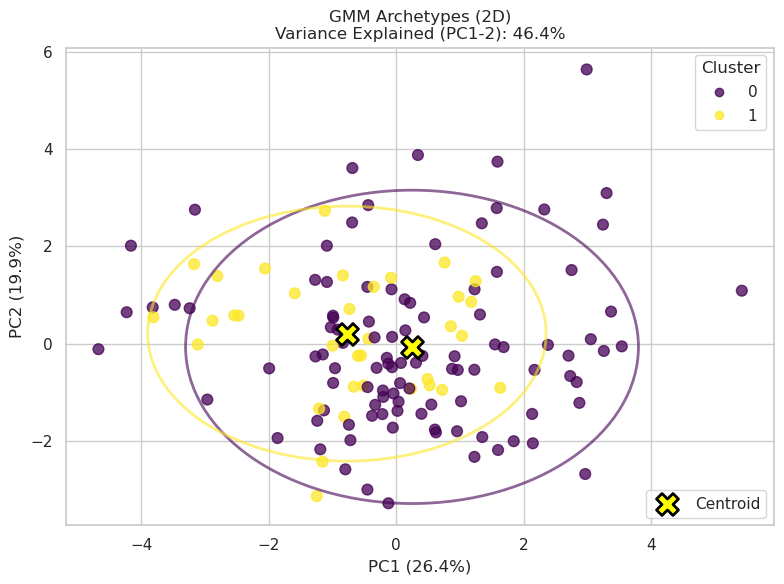

In [21]:
# =============================================================================
# 2D PCA VISUALIZATION
# =============================================================================

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(8, 6))

# Training points
sc = ax.scatter(
    train_coords[:, 0],
    train_coords[:, 1],
    c=gmm_labels,
    cmap="viridis",
    s=60,
    alpha=0.75,
)

# Draw Gaussian ellipses
cmap = plt.get_cmap("viridis")

for i in range(optimal_k):

    if GMM_COVARIANCE_TYPE == "diag":
        cov = np.diag(gmm.covariances_[i][:2])
    else:
        cov = gmm.covariances_[i][:2, :2]

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    width, height = 4 * np.sqrt(vals)

    ellipse = Ellipse(
        xy=gmm.means_[i][:2],
        width=width,
        height=height,
        angle=angle,
        edgecolor=cmap(i / (optimal_k - 1)),
        facecolor="none",
        linewidth=2,
        alpha=0.6,
    )

    ax.add_patch(ellipse)

# Plot GMM centroids
ax.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    c="yellow",
    marker="X",
    s=250,
    edgecolors="black",
    linewidth=2,
    zorder=10,
    label="Centroid",
)

ax.set_xlabel(f"PC1 ({pca_cluster.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_cluster.explained_variance_ratio_[1]:.1%})")

ax.set_title(
    f"GMM Archetypes (2D)\n"
    f"Variance Explained (PC1-2): "
    f"{pca_cluster.explained_variance_ratio_[:2].sum():.1%}"
)

# Cluster legend
cluster_legend = ax.legend(
    *sc.legend_elements(),
    title="Cluster",
    loc="upper right"
)
ax.add_artist(cluster_legend)

# Centroid legend
ax.legend(loc="lower right")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "gmm_archetypes_pca_2d.png",
    dpi=150,
)

plt.show()

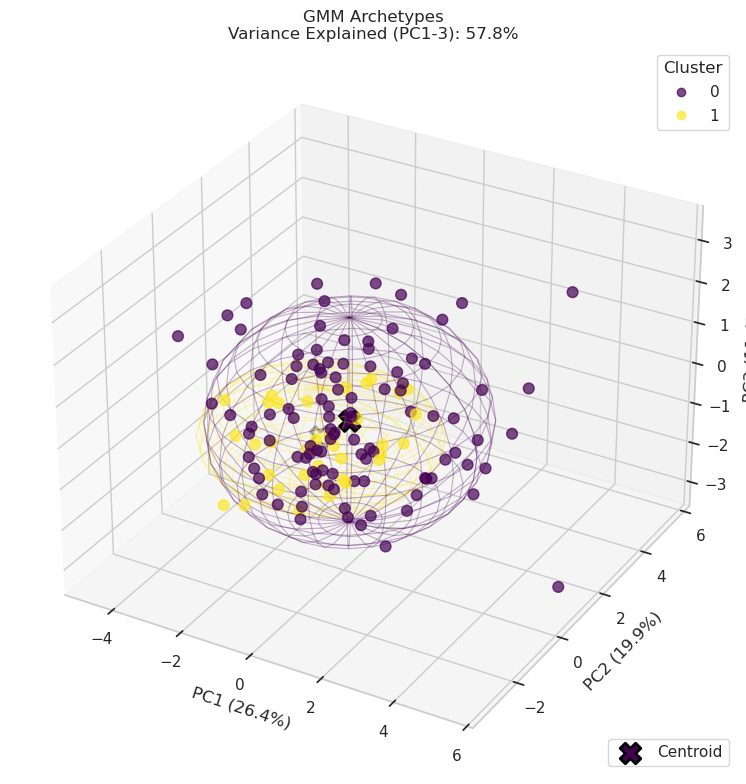

In [22]:
train_coords = X_train_pca

if train_coords.shape[1] >= 3:

    cmap = plt.get_cmap("viridis")
    gmm_means_pca = gmm.means_

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # -------------------------------------------------------------------------
    # Training patients
    # -------------------------------------------------------------------------
    sc = ax.scatter(
        train_coords[:, 0],
        train_coords[:, 1],
        train_coords[:, 2],
        c=gmm_labels,
        cmap="viridis",
        s=60,
        alpha=0.7,
    )

    # -------------------------------------------------------------------------
    # GMM centroids
    # -------------------------------------------------------------------------
    centroid_colors = [
        cmap(i / (optimal_k - 1))
        for i in range(optimal_k)
    ]

    ax.scatter(
        gmm_means_pca[:, 0],
        gmm_means_pca[:, 1],
        gmm_means_pca[:, 2],
        c=centroid_colors,
        marker="X",
        s=220,
        edgecolors="black",
        linewidth=2,
        zorder=10,
        label="Centroid",
    )

    # -------------------------------------------------------------------------
    # Gaussian ellipsoids
    # -------------------------------------------------------------------------
    u = np.linspace(0, 2 * np.pi, 25)
    v = np.linspace(0, np.pi, 15)

    for i in range(optimal_k):

        if GMM_COVARIANCE_TYPE == "diag":
            variances = gmm.covariances_[i]
        else:
            variances = np.diag(gmm.covariances_[i])

        radii = 2 * np.sqrt(variances[:3])

        x = radii[0] * np.outer(np.cos(u), np.sin(v))
        y = radii[1] * np.outer(np.sin(u), np.sin(v))
        z = radii[2] * np.outer(np.ones_like(u), np.cos(v))

        x += gmm_means_pca[i, 0]
        y += gmm_means_pca[i, 1]
        z += gmm_means_pca[i, 2]

        ax.plot_wireframe(
            x,
            y,
            z,
            color=cmap(i / (optimal_k - 1)),
            alpha=0.30,
            linewidth=0.8,
        )

    # -------------------------------------------------------------------------
    # Labels
    # -------------------------------------------------------------------------
    ax.set_xlabel(
        f"PC1 ({pca_cluster.explained_variance_ratio_[0]:.1%})"
    )
    ax.set_ylabel(
        f"PC2 ({pca_cluster.explained_variance_ratio_[1]:.1%})"
    )
    ax.set_zlabel(
        f"PC3 ({pca_cluster.explained_variance_ratio_[2]:.1%})"
    )

    ax.set_title(
        "GMM Archetypes\n"
        f"Variance Explained (PC1-3): "
        f"{pca_cluster.explained_variance_ratio_[:3].sum():.1%}"
    )

    cluster_legend = ax.legend(
        *sc.legend_elements(),
        title="Cluster",
        loc="upper right",
    )

    ax.add_artist(cluster_legend)

    ax.legend(loc="lower right")

else:

    fig, ax = plt.subplots(figsize=(8, 6))

    sc = ax.scatter(
        train_coords[:, 0],
        train_coords[:, 1],
        c=gmm_labels,
        cmap="viridis",
        s=60,
        alpha=0.7,
    )

    centroid_colors = [
        plt.get_cmap("viridis")(i / (optimal_k - 1))
        for i in range(optimal_k)
    ]

    ax.scatter(
        gmm.means_[:, 0],
        gmm.means_[:, 1],
        c=centroid_colors,
        marker="X",
        s=220,
        edgecolors="black",
        linewidth=2,
        label="Centroid",
    )

    ax.set_xlabel(
        f"PC1 ({pca_cluster.explained_variance_ratio_[0]:.1%})"
    )
    ax.set_ylabel(
        f"PC2 ({pca_cluster.explained_variance_ratio_[1]:.1%})"
    )

    ax.set_title("GMM Archetypes (2D)")

    cluster_legend = ax.legend(
        *sc.legend_elements(),
        title="Cluster",
        loc="upper right",
    )

    ax.add_artist(cluster_legend)

    ax.legend(loc="lower right")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "gmm_archetypes_pca.png",
    dpi=150,
)

plt.show()

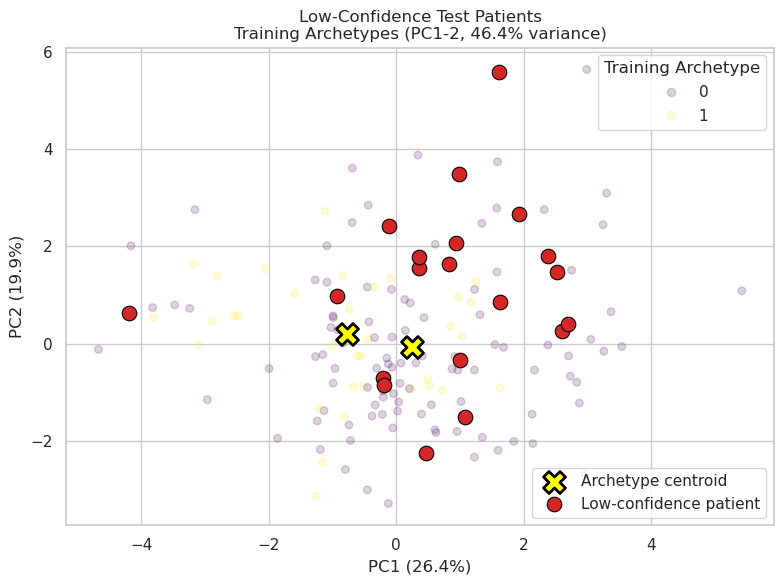

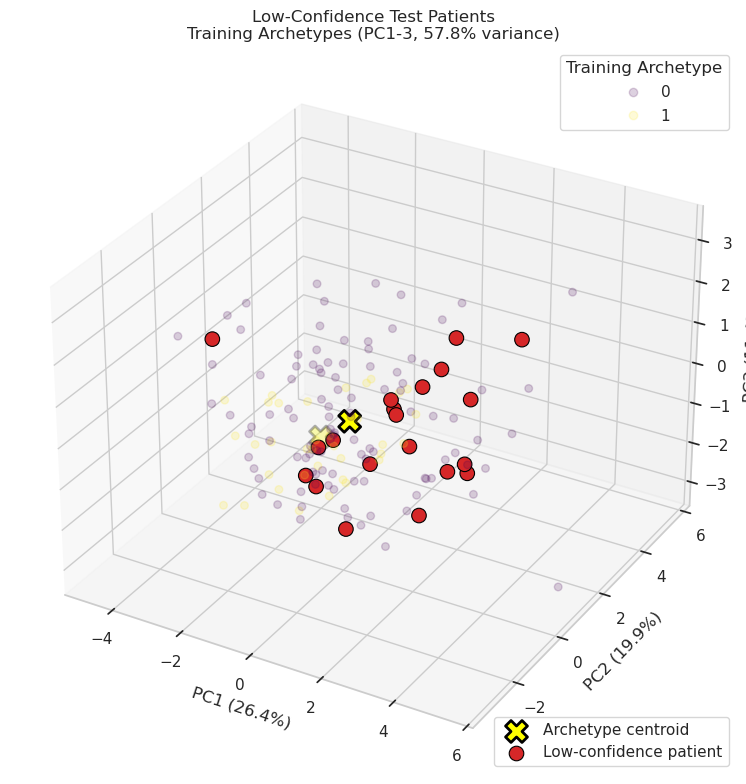

In [23]:
# =============================================================================
# LOW-CONFIDENCE TEST PATIENTS RELATIVE TO GMM ARCHETYPES
# (2D + 3D)
# =============================================================================

train_coords = X_train_pca
test_coords = X_test_pca

low_mask = confidence_tiers == "Low"

cmap = plt.get_cmap("viridis")

# =============================================================================
# 2D FIGURE
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Training patients (colored by archetype)
sc = ax.scatter(
    train_coords[:, 0],
    train_coords[:, 1],
    c=gmm_labels,
    cmap="viridis",
    s=30,
    alpha=0.18,
    zorder=1,
)

# Archetype centroids
ax.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    c="yellow",
    marker="X",
    s=250,
    edgecolors="black",
    linewidth=2,
    zorder=10,
    label="Archetype centroid",
)

# Low-confidence patients
ax.scatter(
    test_coords[low_mask, 0],
    test_coords[low_mask, 1],
    c="#d62728",
    s=110,
    marker="o",
    edgecolors="black",
    linewidth=0.8,
    alpha=1.0,
    zorder=20,
    label="Low-confidence patient",
)

ax.set_xlabel(
    f"PC1 ({pca_cluster.explained_variance_ratio_[0]:.1%})"
)

ax.set_ylabel(
    f"PC2 ({pca_cluster.explained_variance_ratio_[1]:.1%})"
)

ax.set_title(
    "Low-Confidence Test Patients\n"
    f"Training Archetypes (PC1-2, "
    f"{pca_cluster.explained_variance_ratio_[:2].sum():.1%} variance)"
)

cluster_legend = ax.legend(
    *sc.legend_elements(),
    title="Training Archetype",
    loc="upper right",
)

ax.add_artist(cluster_legend)

ax.legend(loc="lower right")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "low_confidence_patients_2d.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# 3D FIGURE
# =============================================================================

if train_coords.shape[1] >= 3:

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Training patients
    sc = ax.scatter(
        train_coords[:, 0],
        train_coords[:, 1],
        train_coords[:, 2],
        c=gmm_labels,
        cmap="viridis",
        s=30,
        alpha=0.18,
    )

    # Archetype centroids
    ax.scatter(
        gmm.means_[:, 0],
        gmm.means_[:, 1],
        gmm.means_[:, 2],
        c="yellow",
        marker="X",
        s=250,
        edgecolors="black",
        linewidth=2,
        label="Archetype centroid",
    )

    # Low-confidence patients
    ax.scatter(
        test_coords[low_mask, 0],
        test_coords[low_mask, 1],
        test_coords[low_mask, 2],
        c="#d62728",
        s=110,
        marker="o",
        edgecolors="black",
        linewidth=0.8,
        alpha=1.0,
        label="Low-confidence patient",
    )

    ax.set_xlabel(
        f"PC1 ({pca_cluster.explained_variance_ratio_[0]:.1%})"
    )

    ax.set_ylabel(
        f"PC2 ({pca_cluster.explained_variance_ratio_[1]:.1%})"
    )

    ax.set_zlabel(
        f"PC3 ({pca_cluster.explained_variance_ratio_[2]:.1%})"
    )

    ax.set_title(
        "Low-Confidence Test Patients\n"
        f"Training Archetypes (PC1-3, "
        f"{pca_cluster.explained_variance_ratio_[:3].sum():.1%} variance)"
    )

    cluster_legend = ax.legend(
        *sc.legend_elements(),
        title="Training Archetype",
        loc="upper right",
    )

    ax.add_artist(cluster_legend)

    ax.legend(loc="lower right")

    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "low_confidence_patients_3d.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

---
## Step 10 (Appendix) – Ground-Truth Sanity Check

*(Unchanged from original.)*
---

In [15]:
if 'true_benefit' in scored_confidence.columns:
    truth_by_tier = scored_confidence.groupby('confidence_tier').agg(
        n=('true_benefit', 'count'),
        avg_true_benefit=('true_benefit', 'mean'),
        avg_predicted_benefit=('benefit_score', 'mean'),
    ).reindex(['High', 'Medium', 'Low']).reset_index()

    vals = truth_by_tier['avg_true_benefit'].tolist()
    is_monotonic = all(vals[i] >= vals[i+1] for i in range(len(vals)-1))

    print('Ground-Truth Validation by Tier:')
    display(truth_by_tier)
    print(f'Monotonicity (High >= Med >= Low): {is_monotonic}')

    corr = scored_confidence['clinical_confidence_score'].corr(scored_confidence['true_benefit'])
    print(f'Pearson corr (confidence vs true benefit): {corr:.3f}')
    truth_by_tier.to_csv(OUTPUT_DIR / 'ground_truth_validation_by_tier.csv', index=False)
else:
    print('No true_benefit column — skipping (expected for real data).')

No true_benefit column — skipping (expected for real data).


---
## Output Index
---

In [16]:
output_files = sorted(OUTPUT_DIR.iterdir())
print(f'Outputs saved to: {OUTPUT_DIR}\n')
for f in output_files:
    print(f'  {f.name}')
print(f'\n--- Summary ---')
print(f'Training reference: {len(high_benefit_train)} high-benefit patients')
print(f'Test scored: {len(high_benefit_test)} high-benefit patients')
print(f'Candidate SHAP features: {N_SHAP_FEATURES} -> {len(CLUSTER_FEATURES)} kept after correlation pruning')
print(f'PCA components for clustering: {pca_cluster.n_components_} (target variance {PCA_VARIANCE_TARGET:.0%})')
print(f'GMM covariance type: {GMM_COVARIANCE_TYPE} (reg_covar={GMM_REG_COVAR})')
print(f'GMM components: {optimal_k} (BIC-optimal, k in [2,5])')
print(f'Stability: {stability_assessment}')
if degenerate_components:
    print(f'Degenerate confidence components excluded: {degenerate_components}')

Outputs saved to: /home/sagemaker-user/prism_repo/Outputs/Clinical-Confidence-Revised/Python

  archetype_summary.csv
  cluster_stability_summary.csv
  confidence_tier_summary.csv
  gmm_archetypes_pca.png
  gmm_bic_aic_selection.png
  scored_confidence_test_patients.csv

--- Summary ---
Training reference: 140 high-benefit patients
Test scored: 60 high-benefit patients
Candidate SHAP features: 12 -> 12 kept after correlation pruning
PCA components for clustering: 8 (target variance 90%)
GMM covariance type: diag (reg_covar=0.001)
GMM components: 2 (BIC-optimal, k in [2,5])
Stability: WEAK
Degenerate confidence components excluded: ['density']
